In [1]:
import pandas as pd

df = pd.read_csv('../data/bus-breakdowns-delays.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (545691, 21)

Columns: ['School_Year', 'Busbreakdown_ID', 'Run_Type', 'Bus_No', 'Route_Number', 'Reason', 'Schools_Serviced', 'Occurred_On', 'Created_On', 'Boro', 'Bus_Company_Name', 'How_Long_Delayed', 'Number_Of_Students_On_The_Bus', 'Has_Contractor_Notified_Schools', 'Has_Contractor_Notified_Parents', 'Have_You_Alerted_OPT', 'Informed_On', 'Incident_Number', 'Last_Updated_On', 'Breakdown_or_Running_Late', 'School_Age_or_PreK']

First 5 rows:


C:\Users\admin\AppData\Local\Temp\ipykernel_13000\3219249487.py:3: DtypeWarning: Columns (0: Incident_Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/bus-breakdowns-delays.csv')


,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,How_Long_Delayed,Number_Of_Students_On_The_Bus,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK
0,2015-2016,1227538,Special Ed AM Run,2621,J711,Heavy Traffic,75003,11/05/2015 08:10:00 AM,11/05/2015 08:12:00 AM,New Jersey,...,NaN,11,Yes,No,Yes,11/05/2015 08:12:00 AM,NaN,11/05/2015 08:12:14 AM,Running Late,School-Age
1,2015-2016,1227539,Special Ed AM Run,1260,M351,Heavy Traffic,06716,11/05/2015 08:10:00 AM,11/05/2015 08:12:00 AM,Manhattan,...,20MNS,2,Yes,Yes,No,11/05/2015 08:12:00 AM,NaN,11/05/2015 08:13:34 AM,Running Late,School-Age
2,2015-2016,1227540,Pre-K/EI,418,3,Heavy Traffic,C445,11/05/2015 08:09:00 AM,11/05/2015 08:13:00 AM,Bronx,...,15MIN,8,Yes,Yes,Yes,11/05/2015 08:13:00 AM,NaN,11/05/2015 08:13:22 AM,Running Late,Pre-K
3,2015-2016,1227541,Special Ed AM Run,4522,M271,Heavy Traffic,02699,11/05/2015 08:12:00 AM,11/05/2015 08:14:00 AM,Manhattan,...,15 MIN,6,No,No,No,11/05/2015 08:14:00 AM,NaN,11/05/2015 08:14:04 AM,Running Late,School-Age
4,2015-2016,1227542,Special Ed AM Run,3124,M373,Heavy Traffic,02116,11/05/2015 08:13:00 AM,11/05/2015 08:14:00 AM,Manhattan,...,NaN,6,No,No,No,11/05/2015 08:14:00 AM,NaN,11/05/2015 08:14:08 AM,Running Late,School-Age


In [3]:
# Cell 1 - Load data cleanly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/bus-breakdowns-delays.csv', low_memory=False)

print("Shape:", df.shape)
print("\nDataset loaded successfully!")

Shape: (545691, 21)

Dataset loaded successfully!


In [4]:
# Cell 2 - Basic information about the dataset
print("=== DATASET INFO ===")
print(df.info())

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 545691 entries, 0 to 545690
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   School_Year                      545691 non-null  str  
 1   Busbreakdown_ID                  545691 non-null  int64
 2   Run_Type                         545685 non-null  str  
 3   Bus_No                           545678 non-null  str  
 4   Route_Number                     545684 non-null  str  
 5   Reason                           545689 non-null  str  
 6   Schools_Serviced                 545684 non-null  str  
 7   Occurred_On                      545691 non-null  str  
 8   Created_On                       545691 non-null  str  
 9   Boro                             534474 non-null  str  
 10  Bus_Company_Name                 545691 non-null  str  
 11  How_Long_Delayed                 491627 non-null  str  
 12  Number_Of_Students_O

In [5]:
# Cell 3 - Check missing values
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent': missing_percent
})
print(missing_table[missing_table['Missing Count'] > 0])

=== MISSING VALUES ===
                  Missing Count  Missing Percent
Run_Type                      6         0.001100
Bus_No                       13         0.002382
Route_Number                  7         0.001283
Reason                        2         0.000367
Schools_Serviced              7         0.001283
Boro                      11217         2.055559
How_Long_Delayed          54064         9.907438
Incident_Number          534801        98.004365


In [6]:
# Drop Incident_Number - 98% missing, completely useless
df.drop(columns=['Incident_Number'], inplace=True)

print("Incident_Number column dropped.")
print("New shape:", df.shape)

Incident_Number column dropped.
New shape: (545691, 20)


In [7]:
# Drop rows where these critical columns are missing
# These have less than 0.01% missing - safe to drop
df.dropna(subset=['Run_Type', 'Bus_No', 'Route_Number', 
                  'Reason', 'Schools_Serviced'], inplace=True)

print("Rows with critical missing values dropped.")
print("New shape:", df.shape)

Rows with critical missing values dropped.
New shape: (545665, 20)


In [10]:
# Fill missing Boro with 'Unknown'
# We keep these rows because other features are still useful
df['Boro'] = df['Boro'].fillna('Unknown')   # new way - clean

print("Boro missing values filled with 'Unknown'")
print("Boro value counts:")
print(df['Boro'].value_counts())

Boro missing values filled with 'Unknown'
Boro value counts:
Boro
Manhattan          135707
Bronx              133420
Brooklyn           125452
Queens              80224
Staten Island       26566
Nassau County       15729
Westchester         11744
Unknown             11217
New Jersey           2601
All Boroughs         1375
Rockland County      1247
Connecticut           383
Name: count, dtype: int64


In [11]:
# Our target variable is Breakdown_or_Running_Late
# It currently contains text - we convert to 0 and 1

print("Current values in target column:")
print(df['Breakdown_or_Running_Late'].value_counts())

# 1 = Running Late (delayed)
# 0 = Breakdown (different type of issue)
df['delayed'] = (df['Breakdown_or_Running_Late'] == 'Running Late').astype(int)

print("\nNew target column 'delayed':")
print(df['delayed'].value_counts())
print("\nClass balance (%):")
print(df['delayed'].value_counts(normalize=True) * 100)

Current values in target column:
Breakdown_or_Running_Late
Running Late    496154
Breakdown        49511
Name: count, dtype: int64

New target column 'delayed':
delayed
1    496154
0     49511
Name: count, dtype: int64

Class balance (%):
delayed
1    90.926484
0     9.073516
Name: proportion, dtype: float64


In [12]:
print("=== TOP REASONS FOR DELAY ===")
print(df['Reason'].value_counts().head(10))

=== TOP REASONS FOR DELAY ===
Reason
Heavy Traffic                  341960
Other                           79949
Mechanical Problem              51807
Won`t Start                     18111
Flat Tire                       13576
Problem Run                     12823
Weather Conditions              10417
Late return from Field Trip      8230
Accident                         4894
Delayed by School                3898
Name: count, dtype: int64


In [ ]:
print("=== RUN TYPES ===")
print(df['Run_Type'].value_counts())


In [13]:
# Convert Occurred_On to datetime and extract hour
# This tells us WHEN delays happen most
df['Occurred_On'] = pd.to_datetime(df['Occurred_On'])
df['hour'] = df['Occurred_On'].dt.hour
df['day_of_week'] = df['Occurred_On'].dt.day_name()

print("Hour column sample:")
print(df['hour'].value_counts().sort_index().head(10))

print("\nDay of week counts:")
print(df['day_of_week'].value_counts())


Hour column sample:
hour
0       924
1       763
2      1303
3       475
4       136
5     13582
6    162566
7    193919
8     49230
9      3923
Name: count, dtype: int64

Day of week counts:
day_of_week
Monday       112669
Wednesday    110396
Tuesday      109589
Thursday     108872
Friday       104136
Sunday            3
Name: count, dtype: int64


In [14]:
# This column has messy text like "15 MIN", "20MNS", "30"
# We need to extract just the number

print("Sample values in How_Long_Delayed:")
print(df['How_Long_Delayed'].value_counts().head(20))


Sample values in How_Long_Delayed:
How_Long_Delayed
31-45 Min     119479
16-30 Min     111474
46-60 Min      64957
0-15 Min       40152
61-90 Min      27711
20 MINS         5730
30 MINS         4688
30 minutes      3757
15 mins         3538
30MINS          3207
20 mins         3170
20 min          2940
30 min          2928
15 MINS         2853
20 MIN          2624
30 MIN          2539
20              2499
15MINS          1989
30 mins         1903
15 minutes      1787
Name: count, dtype: int64


In [15]:
import re

def clean_delay(value):
    if pd.isnull(value):
        return np.nan
    
    value = str(value).strip().upper()
    
    # Handle ranges like "31-45 Min" → take lower bound → 31
    range_match = re.match(r'(\d+)\s*-\s*(\d+)', value)
    if range_match:
        return int(range_match.group(1))
    
    # Handle plain numbers like "20", "30"
    number_match = re.match(r'^(\d+)', value)
    if number_match:
        return int(number_match.group(1))
    
    return np.nan

df['delay_minutes'] = df['How_Long_Delayed'].apply(clean_delay)

print("Cleaned delay_minutes column:")
print(df['delay_minutes'].describe())
print("\nSample values:")
print(df['delay_minutes'].value_counts().head(10))

Cleaned delay_minutes column:
count    491057.000000
mean         28.436811
std         318.312178
min           0.000000
25%          16.000000
50%          30.000000
75%          31.000000
max      202340.000000
Name: delay_minutes, dtype: float64

Sample values:
delay_minutes
31.0    119483
16.0    111498
46.0     64957
0.0      40236
20.0     30521
61.0     27711
30.0     27393
15.0     20602
25.0     11369
10.0     11283
Name: count, dtype: int64


In [16]:
# Fill missing delay_minutes with median
# We use median not mean because delay data is skewed
median_delay = df['delay_minutes'].median()
df['delay_minutes'] = df['delay_minutes'].fillna(median_delay)

print(f"Median delay used for filling: {median_delay} minutes")
print(f"Missing values remaining: {df['delay_minutes'].isnull().sum()}")

Median delay used for filling: 30.0 minutes
Missing values remaining: 0


In [17]:
# Select only the columns we need for modelling
# Drop columns that are IDs, timestamps, or redundant

features_to_keep = [
    'Run_Type',           # Type of bus run
    'Reason',             # Why delayed
    'Boro',               # Which borough
    'Bus_Company_Name',   # Which company
    'hour',               # What hour of day
    'day_of_week',        # What day
    'delay_minutes',      # How long delayed
    'Number_Of_Students_On_The_Bus',  # How many students
    'School_Age_or_PreK', # Type of students
    'delayed'             # TARGET variable
]

df_model = df[features_to_keep].copy()

print("Final dataset shape:", df_model.shape)
print("\nMissing values in final dataset:")
print(df_model.isnull().sum())
print("\nFirst 3 rows:")
df_model.head(3)

Final dataset shape: (545665, 10)

Missing values in final dataset:
Run_Type                         0
Reason                           0
Boro                             0
Bus_Company_Name                 0
hour                             0
day_of_week                      0
delay_minutes                    0
Number_Of_Students_On_The_Bus    0
School_Age_or_PreK               0
delayed                          0
dtype: int64

First 3 rows:


,Run_Type,Reason,Boro,Bus_Company_Name,hour,day_of_week,delay_minutes,Number_Of_Students_On_The_Bus,School_Age_or_PreK,delayed
0,Special Ed AM Run,Heavy Traffic,New Jersey,"RELIANT TRANS, INC. (B232",8,Thursday,30.0,11,School-Age,1
1,Special Ed AM Run,Heavy Traffic,Manhattan,HOYT TRANSPORTATION CORP.,8,Thursday,20.0,2,School-Age,1
2,Pre-K/EI,Heavy Traffic,Bronx,"G.V.C., LTD.",8,Thursday,15.0,8,Pre-K,1


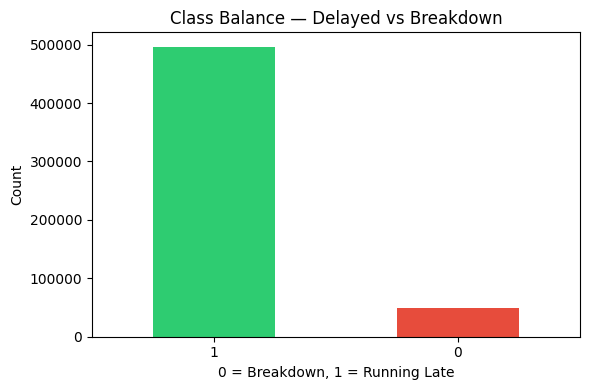

Plot 1 saved!


In [18]:
plt.figure(figsize=(6, 4))
df_model['delayed'].value_counts().plot(kind='bar', 
                                         color=['#2ecc71', '#e74c3c'])
plt.title('Class Balance — Delayed vs Breakdown')
plt.xlabel('0 = Breakdown, 1 = Running Late')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../notebooks/plot1_class_balance.png')
plt.show()
print("Plot 1 saved!")

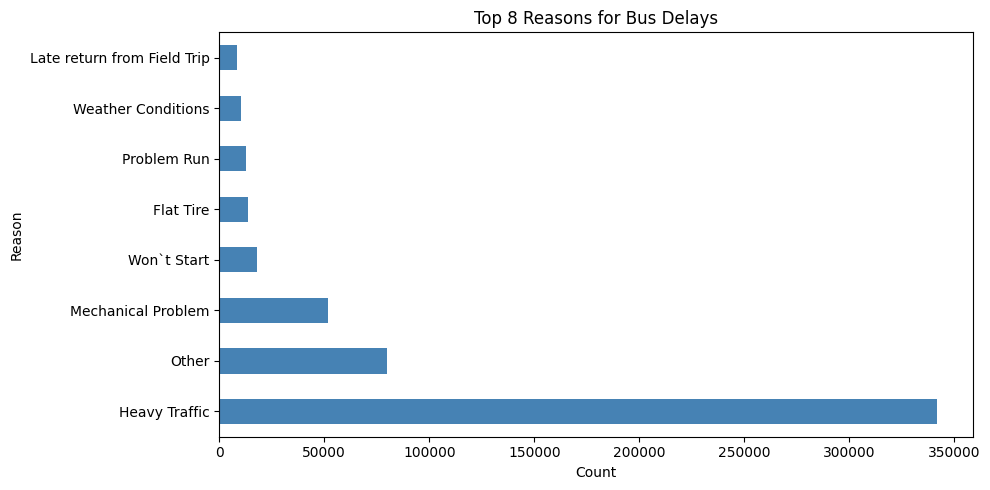

Plot 2 saved!


In [19]:
plt.figure(figsize=(10, 5))
df_model['Reason'].value_counts().head(8).plot(kind='barh', 
                                                color='steelblue')
plt.title('Top 8 Reasons for Bus Delays')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('../notebooks/plot2_delay_reasons.png')
plt.show()
print("Plot 2 saved!")

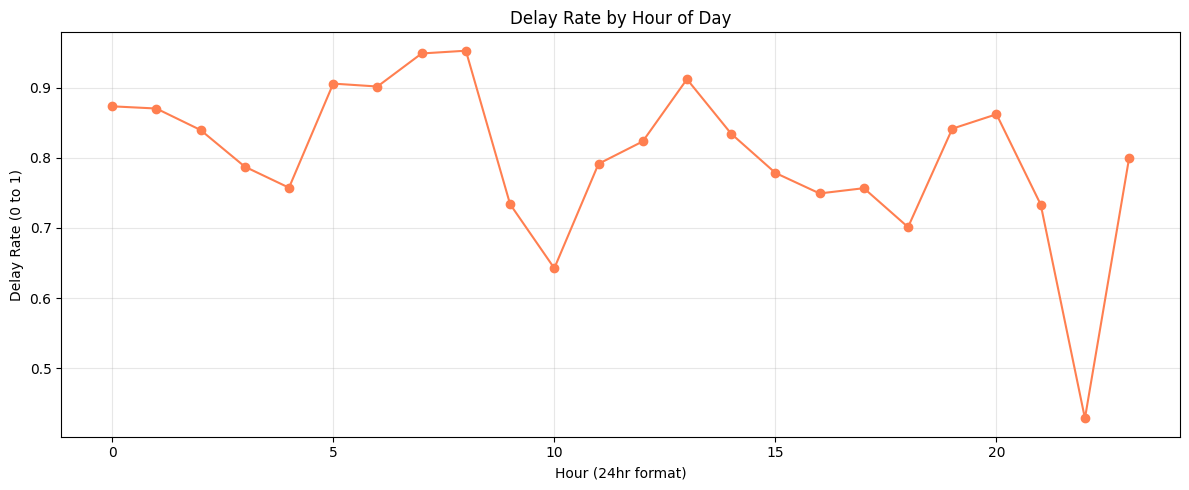

Plot 3 saved!


In [20]:
plt.figure(figsize=(12, 5))
df_model.groupby('hour')['delayed'].mean().plot(kind='line', 
                                                 marker='o',
                                                 color='coral')
plt.title('Delay Rate by Hour of Day')
plt.xlabel('Hour (24hr format)')
plt.ylabel('Delay Rate (0 to 1)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/plot3_delay_by_hour.png')
plt.show()
print("Plot 3 saved!")

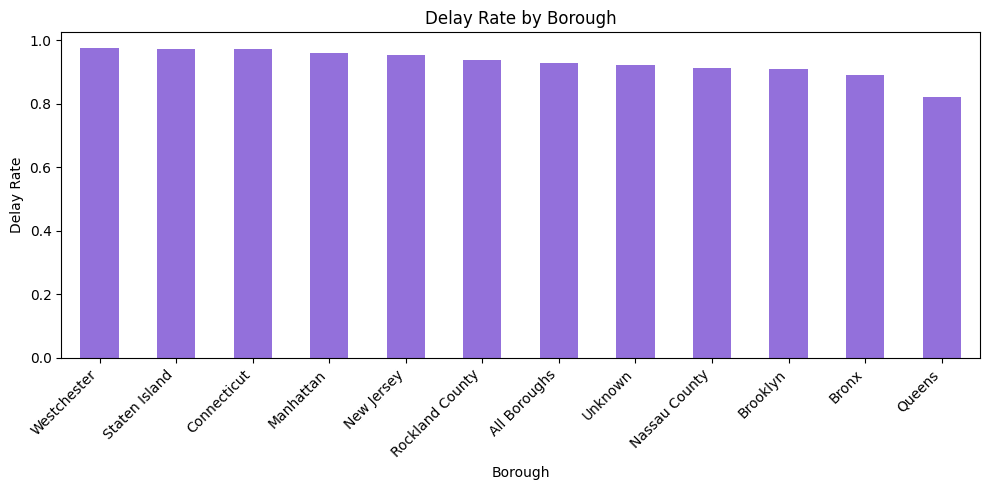

Plot 4 saved!


In [21]:
plt.figure(figsize=(10, 5))
boro_delay = df_model.groupby('Boro')['delayed'].mean().sort_values(ascending=False)
boro_delay.plot(kind='bar', color='mediumpurple')
plt.title('Delay Rate by Borough')
plt.xlabel('Borough')
plt.ylabel('Delay Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/plot4_delay_by_boro.png')
plt.show()
print("Plot 4 saved!")

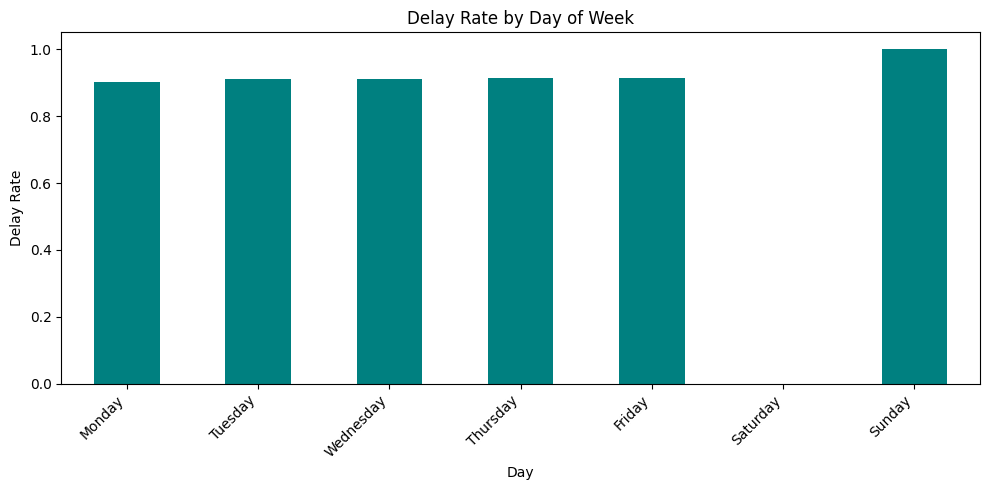

Plot 5 saved!


In [22]:
# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
             'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
day_delay = df_model.groupby('day_of_week')['delayed'].mean()
day_delay = day_delay.reindex(day_order)
day_delay.plot(kind='bar', color='teal')
plt.title('Delay Rate by Day of Week')
plt.xlabel('Day')
plt.ylabel('Delay Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/plot5_delay_by_day.png')
plt.show()
print("Plot 5 saved!")